# 2. Data Preparation

> **CRISP-DM Phase 3:** Transform raw data into a clean, merged **Analytical Base Table (ABT)** ready for modelling.

> 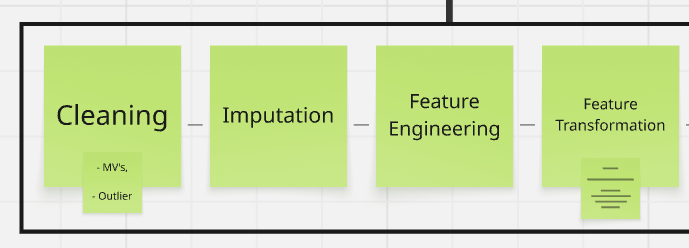

## Table of Contents

- [1.1 Overview](#11-overview)
- [1.2 Setup](#12-setup)
- [2.1 Load Raw Datasets](#21-load-raw-datasets)
- [2.2 Remove Irrelevant Features](#22-remove-irrelevant-features)
- [2.3 Handling Missing Values](#23-handling-missing-values)
- [2.4 Handling Duplicates](#24-handling-duplicates)
- [2.5 Outliers Report](#25-outliers-report)
- [2.6 Merge Datasets → Analytical Base Table (ABT)](#26-merge-datasets--analytical-base-table-abt)
- [2.7 ABT Quality Check](#27-abt-quality-check) (REVIEW)
- [2.8 Feature Engineering](#28-feature-engineering) (TO DO)
- [2.9 Feature Encoding](#29-feature-encoding)
- [2.10 Save ABT](#29-save-abt)
- [2.11 Subset ABT for First Objective](#210-subset-abt-for-first-objective) (REVIEW)

## 1.1 Overview

This notebook covers the **Data Preparation** phase of the project, which transforms the raw datasets into a clean, unified **Analytical Base Table (ABT)** ready for feature engineering and modelling.

The preparation is structured into the following steps:

- **2.1 Load Raw Datasets** — load all raw data sources into memory.
- **2.2 Remove Irrelevant Features** — drop columns identified during Data Understanding as having no analytical value, and convert date columns to the correct `datetime` type.
- **2.3 Handling Missing Values** — detect and impute missing values per data type: median for numerics, forward fill for datetimes, and `"Unknown"` for categoricals.
- **2.4 Handling Duplicates** — remove exact duplicate rows and resolve key-level duplicates by keeping the most complete record.
- **2.5 Outliers Report** — flag potential outliers in numeric columns using IQR and Z-score methods. No data is modified at this stage — results are reported for review.
- **2.6 Merge Datasets → ABT** — join the cleaned datasets into a single Analytical Base Table.
- **2.7 ABT Quality Check** — validate the result of the merge: shape, new missing values introduced by the join, and key coverage.
- **2.8 Feature Engineering** — create new variables from existing ones to enrich the ABT for modelling.
- **2.9 Feature Encoding** — ordinal encoding of the categorical variables with hierarchical order.
- **2.10 Save ABT** — persist the final ABT for use in subsequent notebooks.
- **2.11 Subset ABT for First Objective** — filter and prepare a focused subset of the ABT tailored to the first modelling objective.

To ensure consistency across datasets, steps 2.2 to 2.5 rely on reusable functions defined once and applied to each dataset individually before the merge.

---
## 1.2 Setup

In [1]:
import importlib
import sys, os

# Ensure project root is on path
sys.path.insert(0, os.path.abspath(".."))

import src.code.data_preparation as dp
import src.code.data_functions as dfun
import src.code.io_utils as io

importlib.reload(dp)
importlib.reload(dfun)
importlib.reload(io)

import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

# Path constants
BDOSS_PATH    = io.data_path("bdoss.csv")
CRC_PATH      = io.data_path("crc.csv")
CREDSCORE_PATH = io.data_path("credscore.csv")
FAMA_PATH     = io.data_path("fama.csv")
ABT_OUT_PATH  = "../data/prepared/abt.parquet"

print("Setup complete.")

Setup complete.


---
## 2.1 Load Raw Datasets

> All four datasets are loaded from the `../data/converted/` folder (CSV format).  
> Loading uses `io_utils.load()`, which prints shape information automatically.

In [2]:
# Main loan-level dataset - large, takes a few seconds to load
bdoss_raw = io.load(BDOSS_PATH)
bdoss_raw.head(3)

[LOAD] /Users/mtp/Desktop/NOVA IMS/2nd semester/Business Cases with Data Science/Case 1/Business_Case_BNP/data/converted/bdoss.csv | shape: (2658187, 35)


,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,P,CL,EP,0.000,ENC,2024-01-31,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.000,69.000,69.000,20000.000,20000.000,347.447,NaN,13208.455,0.000,NaN,0.000,0.000,000000000000000000000000,0.000,120.000,P,1113.258,80.000,1988.000,P,2845,1.000,A
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,P,CL,EP,0.000,SAN,2024-01-31,2019-01-28,2019-02-04,2019-02-04,2022-12-28,72.000,34.000,34.000,2500.000,2500.000,56.018,NaN,0.000,0.000,NaN,1.000,1.000,000000000000210210000110,0.000,120.000,N,838.186,91.000,1990.000,P,2855,0.000,A
2,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,P,CL,EP,0.000,ENC,2024-01-31,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84.000,52.000,52.000,5000.000,5000.000,100.074,NaN,2665.191,0.000,NaN,0.000,0.000,000000000000000000000000,0.000,118.000,P,1314.144,80.000,2013.000,P,2635,2.000,W


In [3]:
# Credit bureau monthly data
crc_raw = io.load(CRC_PATH)
crc_raw.head(3)

[LOAD] /Users/mtp/Desktop/NOVA IMS/2nd semester/Business Cases with Data Science/Case 1/Business_Case_BNP/data/converted/crc.csv | shape: (3034921, 22)


,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2023-12-31,NaN,1.000,4.000,0.000,0.000,0.000,1.000,6.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,6842.100,963.550,0.000,0.000
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,2023-12-31,547.180,4.000,5.000,0.000,0.000,0.000,1.000,10.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,28532.060,7115.460,0.000,0.000
2,0000f858346061c53064586a3347b34659565a6712d004...,2023-12-31,NaN,1.000,5.000,1.000,1.000,0.000,0.000,8.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2957.280,2150.900,2408.560,85549.490


In [4]:
# Credit score per customer
credscore_raw = io.load(CREDSCORE_PATH)
credscore_raw.head(3)

[LOAD] /Users/mtp/Desktop/NOVA IMS/2nd semester/Business Cases with Data Science/Case 1/Business_Case_BNP/data/converted/credscore.csv | shape: (63704, 5)


,CONTRIB,sys_numero_submissao,sys_data_procura,kp_sqe,ks_score_tier
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,22.000,2025-02-05,H,2.000
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,4.000,2025-04-09,D,1.000
2,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,1.000,2023-08-08,F,3.000


In [5]:
# Aggregated customer-level features + socio-demographics
fama_raw = io.load(FAMA_PATH)
fama_raw.head(3)

[LOAD] /Users/mtp/Desktop/NOVA IMS/2nd semester/Business Cases with Data Science/Case 1/Business_Case_BNP/data/converted/fama.csv | shape: (141115, 23)


,CONTRIB,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b...,2024-11-30,15.000,6.000,9.000,1.000,0.000,88784.040,0.000,88784.040,0.000,4443.000,-808.000,1280.533,0.000,1153.000,1153.000,120.000,0.425,15.000,C,P,62
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f420...,2024-11-30,6.000,4.000,2.000,1.000,2.000,9584.910,7628.410,9584.910,0.000,3120.000,-2077.000,466.333,14.000,1564.667,1582.000,72.000,0.139,6.000,C,A,65
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d0...,2024-11-30,8.000,5.000,3.000,1.000,0.000,22000.860,0.000,22000.860,0.000,4936.000,-2089.000,907.625,0.000,1765.000,1765.000,36.000,0.278,8.000,C,L,65


---
## 2.2 Remove irrelevant features
During the **Data Understanding** phase, we identified across the datasets a set of columns that are not relevant for the analysis and should be dropped, as well as columns stored as strings that represent dates and need to be converted to the correct `datetime` type.
The decisions taken were:

* **Remove columns that were identified as irrelevant** — duplicated identifiers, free-text fields with no analytical value, or internal system columns that carry no signal for the problem at hand.
* **Convert to datetime column**s that represent dates or timestamps but were loaded as strings, so that time-based operations and feature engineering can be applied correctly downstream.

To keep this step consistent and reusable across all datasets, we defined a single function **initial_preparation()** that handles both operations. Columns passed that do not exist in a given dataset are silently ignored, since not all datasets share the same structure.

### 2.2.1 Clean  `bdoss`

In [6]:
bdoss_clean = dp.clean_bdoss(bdoss_raw)

[clean_bdoss] Dropping 1 fully-null cols: ['MENSALIDADE_CORR']
[clean_bdoss] shape: (2658187, 29) | RISK distribution:
{0: 2414813, -9223372036854775808: 122135, 10000000: 8712, 100000000: 5957, 1000000000: 5424, 10000000000: 5016, 100000000000: 4644, 1000000000000: 4377, 10000000000000: 3899, 1000000000000000: 3645, 100000000000000: 3611, 10000000000000000: 3356, 100000000000000000: 3145, 1000000000000000000: 3075, 110000000: 1725, 20000000: 1413, 120000000: 1026, 1100000000: 747, 200000000: 730, 2000000000: 718, 20000000000: 598, 210000000: 596, 11000000000: 590, 2000000000000: 584, 1110000000: 581, 200000000000: 558, 200000000000000: 465, 110000000000: 462, 1220000000: 453, 1100000000000: 446, 11000000000000: 429, 20000000000000000: 415, 1200000000: 413, 20000000000000: 411, 1010000000: 402, 1100000000000000: 401, 2000000000000000000: 387, 10010000000: 358, 110000000000000: 343, 11000000000000000: 343, 2000000000000000: 338, 200000000000000000: 334, 11110000000: 322, 12000000000: 31

### 2.2.2 Clean `crc`

In [7]:
crc_clean = dp.clean_crc(crc_raw)

[clean_crc] shape: (3034921, 24)


### 2.2.3 Clean `credscore`

In [8]:
credscore_clean = dp.clean_credscore(credscore_raw)

[clean_credscore] shape: (63704, 4)


### 2.2.4 Clean `Fama`

In [9]:
fama_clean = dp.clean_fama(fama_raw)

[clean_fama] shape: (141115, 23)


### Agreggate bdoss -> client dataset -> client variables

client dataset --- is_churn --- when -- sun/sol -- when

---
## 2.3 Handling Missing Values

After the initial preparation, we assessed the presence of missing values across all datasets. The goal of this step is to ensure no nulls are carried forward into feature engineering or modelling, as these can cause errors or silently distort results.

The strategy applied follows the data types identified in each dataset:

- **Numeric columns** — imputed with the **median**, which is more robust to outliers than the mean.
- **Datetime columns** — imputed with **forward fill** (`ffill`), propagating the last known date forward. This is appropriate when records have a natural time order and a missing date is likely close to the previous one.
- **Categorical columns** — filled with `"Unknown"`, making the missingness explicit and preserving the row rather than discarding it.
- **Rows** — any row missing more than 50% of its values is dropped before imputation, as imputing heavily incomplete records would introduce more noise than signal.

As with the previous step, a reusable function `handle_missing_values()` was defined and applied consistently across all datasets.

### 2.3.1 Missing Values `Bdoss`


In [10]:
bdoss_clean = dp.handle_missing_values(df= bdoss_clean,dataset_name= "BDOSS")

[BDOSS]
  Missing before     : 60282
  Rows dropped       : 0  (threshold: >50% missing)
  Numeric imputed  (2) [fixed] : ['RANGCLI', 'NBENF']
  Datetime imputed (0) [ffill]  : —
  Categ.  imputed  (2) [Unknown]  : ['NATIO', 'MODCONTACTO']
  Missing after      : 0



### 2.3.2 Missing Values `CRC`

In [11]:
crc_clean = dp.handle_missing_values(df= crc_clean,dataset_name= "CRC")

[CRC]
  Missing before     : 2005203
  Rows dropped       : 0  (threshold: >50% missing)
  Numeric imputed  (1) [fixed] : ['MT_MENSAL']
  Datetime imputed (0) [ffill]  : —
  Categ.  imputed  (0) [Unknown]  : —
  Missing after      : 0



### 2.3.3 Missing Values `CredScore`

In [12]:
credscore_clean= dp.handle_missing_values(df= credscore_clean,dataset_name= "CredScore")


[CredScore]
  Missing before     : 21921
  Rows dropped       : 0  (threshold: >50% missing)
  Numeric imputed  (1) [fixed] : ['kp_sqe_enc']
  Datetime imputed (0) [ffill]  : —
  Categ.  imputed  (0) [Unknown]  : —
  Missing after      : 0



### 2.3.4 Missing Values `FAMA`

In [13]:
fama_clean= dp.handle_missing_values(df= fama_clean,dataset_name= "Fama")

[Fama]
  Missing before     : 0
  Rows dropped       : 0  (threshold: >50% missing)
  Numeric imputed  (0) [fixed] : —
  Datetime imputed (0) [ffill]  : —
  Categ.  imputed  (0) [Unknown]  : —
  Missing after      : 0



---
## 2.4 Handling Duplicates

With missing values addressed, we then checked for duplicate records across all datasets. Duplicates can silently distort model training by overrepresenting certain records, so it is important to remove them before moving forward.

We distinguish between two types of duplicates:

- **Exact duplicates** — rows that are completely identical across all columns. These are dropped unconditionally, as they carry no additional information.
- **Key duplicates** — rows that share the same primary key (e.g. `order_id`) but differ in other columns, which can happen due to data ingestion issues or system errors. When found, we keep the row with the fewest missing values, as it is the most complete record.

Note that not all datasets have a single unique key per row by design — for example, a dataset with monthly entries per user will naturally repeat `user_id` across rows. In those cases, `key_cols` is not passed and only exact duplicates are removed.

A reusable function `handle_duplicates()` was defined and applied consistently across all datasets.

### 2.4.1 Duplicates `BDOSS`

In [14]:
bdoss_clean = dp.handle_duplicates(
    df=bdoss_clean, dataset_name="BDOSS", key_cols=["CONTRIB", "DOSSIER", "OBS_DATE"]
)

[BDOSS]
  Rows before        : 2658187
  Exact duplicates   : 17 dropped
  Key duplicates     : 278357 dropped  (key: ['CONTRIB', 'DOSSIER', 'OBS_DATE'])
  Rows after         : 2379813  (total dropped: 278374)



### 2.4.2 Duplicates `CRC`

In [15]:
crc_clean = dp.handle_duplicates(
    df=crc_clean, dataset_name="CRC", key_cols=["CONTRIB", "DOSSIER", "OBS_DATE"]
)

[CRC]
  Rows before        : 3034921
  Exact duplicates   : 0 dropped
  Key duplicates     : 0 dropped  (key: ['CONTRIB', 'DOSSIER', 'OBS_DATE'])
  Rows after         : 3034921  (total dropped: 0)



### 2.4.3 Duplicates `CredScore`


In [16]:
credscore_clean = dp.handle_duplicates(
    df=credscore_clean, dataset_name="CredScore", key_cols=["CONTRIB", "sys_data_procura"]
)

[CredScore]
  Rows before        : 63704
  Exact duplicates   : 835 dropped
  Key duplicates     : 546 dropped  (key: ['CONTRIB', 'sys_data_procura'])
  Rows after         : 62323  (total dropped: 1381)



### 2.4.4 Duplicates `FAMA`


In [17]:
fama_clean = dp.handle_duplicates(
    df=fama_clean, dataset_name="FAMA", key_cols=["CONTRIB", "Date_Obs"]
)

[FAMA]
  Rows before        : 141115
  Exact duplicates   : 0 dropped
  Key duplicates     : 0 dropped  (key: ['CONTRIB', 'Date_Obs'])
  Rows after         : 141115  (total dropped: 0)



In [18]:
os.makedirs("../data/prepared", exist_ok=True)

print("Saving cleaned datasets as Parquet...")

io.save(bdoss_clean, "../data/prepared/bdoss_clean.parquet")
print("- BDOSS saved.")

io.save(crc_clean, "../data/prepared/crc_clean.parquet")
print("- CRC saved.")

io.save(credscore_clean, "../data/prepared/credscore_clean.parquet")
print("- CREDSCORE saved.")

io.save(fama_clean, "../data/prepared/fama_clean.parquet")
print("- FAMA saved.")

Saving cleaned datasets as Parquet...
[SAVE] ../data/prepared/bdoss_clean.parquet | shape: (2379813, 29)
- BDOSS saved.
[SAVE] ../data/prepared/crc_clean.parquet | shape: (3034921, 24)
- CRC saved.
[SAVE] ../data/prepared/credscore_clean.parquet | shape: (62323, 4)
- CREDSCORE saved.
[SAVE] ../data/prepared/fama_clean.parquet | shape: (141115, 23)
- FAMA saved.


---
## 2.5 Outliers Report

Before merging the datasets, we ran outlier detection on all numeric columns. At this stage the goal is purely diagnostic — no data is modified. The decision on how to handle each outlier (remove, cap, or leave) will be made in context, after reviewing the results and considering the modelling approach to be used downstream.

Two complementary methods were applied:

- **IQR (Interquartile Range)** — flags values that fall below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR`. More robust to skewed distributions and effective at catching extreme values relative to the bulk of the data.
- **Z-score** — flags values more than 3 standard deviations from the mean. Works best on roughly normal distributions and is more sensitive to moderate but consistent deviations.

Using both methods together gives a fuller picture: a value flagged by both is almost certainly a true outlier, while one flagged by only one method may warrant a closer look.

The function `detect_outliers()` reports the count and percentage of flagged rows per column but does not return a modified DataFrame.

### 2.5.1 Outliers Summary  `BDOSS`

In [19]:
dp.detect_outliers(df=bdoss_clean)

[Dataset] Outlier Detection
  Column                      IQR outliers  Z-score outliers   % rows
  ------------------------- -------------- ----------------- --------
  BICONTRATO                             0                 0     0.0%
  DURDEG                             13106                 0     0.6%
  RANGPRO                             5171              3405     0.2%
  RANGCLI                            34770              6230     1.5%
  MTFINO                            134659             47850     5.7%
  MTFIN                             134671             47850     5.7%
  MENSALIDADE                       142425             47800     6.0%
  CRD                               152623             50574     6.4%
  SREC                              151906              6094     6.4%
  RN                                352272             37920    14.8%
  RD                                352573             94608    14.8%
  RISK                              229717            116360  

### 2.5.2 Outliers Summary  `CRC`

In [20]:
dp.detect_outliers(df=crc_clean)

[Dataset] Outlier Detection
  Column                      IQR outliers  Z-score outliers   % rows
  ------------------------- -------------- ----------------- --------
  MT_MENSAL                         339436              1242    11.2%
  COUNT_CL                          282883             41934     9.3%
  COUNT_CP                          117466             34432     3.9%
  COUNT_AUTO                         52941             52941     1.7%
  COUNT_HT                           44455             44455     1.5%
  COUNT_CONEXO                      193001            193001     6.4%
  COUNT_OTHER                        90843             29180     3.0%
  COUNT_TOTAL                        93557             40653     3.1%
  MONTVENC_CL                       114199              8806     3.8%
  MONTVENC_CP                       135750             18423     4.5%
  MONTVENC_AUTO                      37100              4492     1.2%
  MONTVENC_HT                        18812              1168  

### 2.5.3 Outliers Summary  `CredScore`

In [21]:
dp.detect_outliers(df=credscore_clean)

[Dataset] Outlier Detection
  Column                      IQR outliers  Z-score outliers   % rows
  ------------------------- -------------- ----------------- --------
  ks_score_tier                        825               267     1.3%
  kp_sqe_enc                             0                 0     0.0%
  ------------------------- -------------- ----------------- --------
  TOTAL                                825               267



### 2.5.4 Outliers Summary  `FAMA`

In [22]:
dp.detect_outliers(df=fama_clean)

[Dataset] Outlier Detection
  Column                      IQR outliers  Z-score outliers   % rows
  ------------------------- -------------- ----------------- --------
  ALLBD_N_Dossiers__N                 5393              2073     3.8%
  ALLBD_N_CL__N                       5897              2112     4.2%
  ALLBD_N_CP__N                       3199              2119     2.3%
  ALLBD_A_CL__N                       1347              1347     1.0%
  ALLBD_A_CP__N                       3626               554     2.6%
  ALLBD_MTFINO_CL__N                  9220              2839     6.5%
  ALLBD_MTFINO_CP__N                 14926              2380    10.6%
  ALLBD_MTFIN_CL__N                   9156              2647     6.5%
  ALLBD_MTFIN_CP__N                  27906              3949    19.8%
  ALLBD_IDADE_MSA__N                     1                 1     0.0%
  ALLBD_IDADE_MIN__N                  7537              2968     5.3%
  ALLBD_IDADE_MEAN__N                 1613               885  

---
## 2.6 Merge Datasets $\rightarrow$ Analytical Base Table (ABT)

Join strategy:
```
bdoss (base)   LEFT JOIN  crc        ON [CONTRIB, OBS_DATE]
               LEFT JOIN  credscore  ON [CONTRIB]
               LEFT JOIN  fama       ON [CONTRIB]
```
Using **left join** ensures we keep all bdoss records even if bureau/score data is missing for some customers.

In [23]:
abt = dp.merge_datasets(bdoss_clean, crc_clean, credscore_clean, fama_clean)

print(f"\nFinal ABT shape: {abt.shape}")
display(abt.head(3))

[merge] Starting merge...
[merge] Final ABT shape: (2382660, 76)
[merge] Overall missing: 4.49%
[merge] RISK distribution:
{0: 2152143, -9223372036854775808: 116842, 10000000: 8132, 100000000: 5542, 1000000000: 4997, 10000000000: 4729, 100000000000: 4365, 1000000000000: 4086, 10000000000000: 3636, 1000000000000000: 3425, 100000000000000: 3384, 10000000000000000: 3157, 100000000000000000: 2934, 1000000000000000000: 2870, 110000000: 1605, 20000000: 1301, 120000000: 985, 1100000000: 689, 200000000: 684, 2000000000: 654, 20000000000: 564, 2000000000000: 552, 1110000000: 540, 210000000: 535, 200000000000: 531, 11000000000: 524, 200000000000000: 444, 1220000000: 437, 110000000000: 431, 1100000000000: 407, 11000000000000: 405, 1200000000: 394, 20000000000000000: 375, 20000000000000: 373, 1010000000: 365, 1100000000000000: 348, 10010000000: 345, 2000000000000000000: 344, 200000000000000000: 328, 2000000000000000: 325, 110000000000000: 323, 11000000000000000: 322, 11110000000: 309, 12000000000:

,CONTRIB,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,CRD,SREC,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,NATIO,PTT,NBENF,MODCONTACTO,RISK_EVER,RISK_RECENT,MT_MENSAL,...,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT,crc_total_overdue,crc_total_debt,sys_data_procura,ks_score_tier,kp_sqe_enc,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,P,CL,EP,0.000,ENC,2024-01-31,120.000,69.000,69.000,20000.000,20000.000,347.447,13208.455,0.000,0.000,0.000,0,0.000,120.000,P,1113.258,80.000,P,2845,1.000,A,0,0,547.450,...,7162.060,0.000,0.000,0.000,35384.750,2025-04-09,1.000,3.000,2024-11-30,10.000,5.000,5.000,1.000,0.000,20000.000,0.000,20000.000,0.000,4453.000,-1928.000,1166.900,0.000,850.000,850.000,120.000,0.675,10.000,C,P,52.000
1,758dd5c2ae8f1b6ce83811a8793ec86e80ea51228cf7f6...,P,CL,EP,0.000,ENC,2025-04-30,84.000,24.000,25.000,10000.000,10000.000,194.090,9354.266,0.000,0.000,0.000,0,0.000,120.000,P,2359.172,60.000,P,2700,0.000,W,0,0,0.000,...,0.000,0.000,258577.110,0.000,494689.350,NaT,NaN,NaN,2024-11-30,9.000,5.000,4.000,1.000,0.000,10785.950,0.000,10785.950,0.000,1447.000,-1808.000,266.444,0.000,1750.000,1750.000,84.000,0.250,9.000,S,A,44.000
2,758e40c5750b79f43440e8aa4d54e07f091d8207b79d88...,P,CL,EPF,0.000,ENC,2025-04-30,72.000,63.000,63.000,5800.000,5800.000,135.443,1082.527,0.000,0.000,0.000,0,0.000,118.000,P,919.171,70.000,P,2765,0.000,A,0,0,117.400,...,40.140,0.000,0.000,0.000,1084.400,NaT,NaN,NaN,2024-11-30,8.000,5.000,3.000,1.000,0.000,11131.320,0.000,11131.320,0.000,2951.000,-584.000,1078.000,0.000,707.000,707.000,72.000,0.833,8.000,C,F,60.000


# IMPORTANT NOTE:
Some clients dont have values because they not existe in the main table, so this is the type of decision that we need to think how we are going to handle before moving to the FE

---
## 2.7 ABT Quality Check

A structured set of coherence checks on the merged ABT. Each subsection targets a different dimension of data quality:

- **2.7.1 Shape & Duplicates** — row count sanity and exact-duplicate check
- **2.7.2 Key Uniqueness** — verify `CONTRIB + OBS_DATE` is unique per row (or detect multi-loan customers)
- **2.7.3 Join Coverage** — % of bdoss rows matched by each left-join source
- **2.7.4 Missing Values Summary** — overall & per-column null breakdown
- **2.7.5 Date Logic Coherence** — check temporal orderings (creation ≤ start ≤ end)
- **2.7.6 Numeric Range Sanity** — flag impossible values (negative durations, ages, etc)
- **2.7.7 Near-Constant Columns** — detect low-variance columns unlikely to add signal
- **2.7.8 RISK Distribution** — inspect the target variable before encoding
- **2.7.9 Data Types & Feature Inventory** — final column list and type summary

### 2.7.1 Shape & Duplicates

In [24]:
print(f"ABT shape        : {abt.shape[0]:,} rows × {abt.shape[1]} columns")
print(f"bdoss_clean rows : {bdoss_clean.shape[0]:,}")

assert abt.shape[0] > 0, "ABT is empty!"
assert abt.shape[0] >= bdoss_clean.shape[0], "ABT has FEWER rows than bdoss — left-join lost records!"

n_dup = abt.duplicated().sum()
print(f"Exact duplicate rows : {n_dup}")
if n_dup > 0:
    print(f"  WARNING: {n_dup} exact duplicates found. Consider deduplication.")
else:
    print("  OK! No exact duplicates.")

print("\nAll shape & duplicate checks passed.")

ABT shape        : 2,382,660 rows × 76 columns
bdoss_clean rows : 2,379,813
Exact duplicate rows : 0
  OK! No exact duplicates.

All shape & duplicate checks passed.


### 2.7.2 Key Uniqueness

In [25]:
# bdoss is a loan × observation-month table, so the granularity key is (CONTRIB, OBS_DATE) if each loan has one record per month, or 
# (CONTRIB, DOSSIER, OBS_DATE) if a customer has multiple loans. We check both and report.

key_contrib_obs = ["CONTRIB", "OBS_DATE"]
n_dup_key = abt.duplicated(subset=key_contrib_obs).sum()
n_unique_key = abt[key_contrib_obs].drop_duplicates().shape[0]

print(f"(CONTRIB, OBS_DATE) key:")
print(f"  Total rows         : {len(abt):,}")
print(f"  Unique key combos  : {n_unique_key:,}")
print(f"  Duplicate key rows : {n_dup_key:,}")

if n_dup_key > 0:
    print("  INFO: Multi-loan customers detected (same CONTRIB + OBS_DATE in multiple rows). This is ok and expected.")
else:
    print("  OK! (CONTRIB, OBS_DATE) is unique per row.")

# Also check CONTRIB alone
n_unique_contrib = abt["CONTRIB"].nunique()
print(f"\nUnique customers (CONTRIB) : {n_unique_contrib:,}")

(CONTRIB, OBS_DATE) key:
  Total rows         : 2,382,660
  Unique key combos  : 2,379,813
  Duplicate key rows : 2,847
  INFO: Multi-loan customers detected (same CONTRIB + OBS_DATE in multiple rows). This is ok and expected.

Unique customers (CONTRIB) : 148,729


### 2.7.3 Join Coverage

In [26]:
# For each left-joined source, check what fraction of ABT rows received at least one non-null column from that source

crc_sentinel    = [c for c in ["MT_MENSAL", "COUNT_CL", "COUNT_AUTO", "COUNT_TOTAL"] if c in abt.columns]
cscore_sentinel = [c for c in ["kp_sqe", "ks_score_tier", "sys_numero_submissao"] if c in abt.columns]
fama_sentinel   = [c for c in ["ALLBD_N_Dossiers__N", "sdem_age", "Date_Obs"] if c in abt.columns]

n = len(abt)
print(f"{'Source':<12} {'Matched rows':>15} {'Coverage':>10}")
print("-" * 40)

for source, cols in [("CRC", crc_sentinel), ("CredScore", cscore_sentinel), ("FAMA", fama_sentinel)]:
    if cols:
        matched = abt[cols].notna().any(axis=1).sum()
        print(f"{source:<12} {matched:>15,} {matched/n*100:>9.1f}%")
    else:
        print(f"{source:<12} {'(no sentinel cols found)':>26}")

print(f"\nTotal ABT rows : {n:,}")

Source          Matched rows   Coverage
----------------------------------------
CRC                2,248,756      94.4%
CredScore            965,167      40.5%
FAMA               2,340,395      98.2%

Total ABT rows : 2,382,660


### 2.7.4 Missing Values Summary

In [27]:
assert "RISK" in abt.columns, "RISK column missing from ABT!"
assert abt["RISK"].isnull().sum() == 0, "RISK has nulls — the target must be complete!"
assert (abt.isnull().mean() < 1.0).all(), "At least one column is 100% null! Check the pipeline!"

null_pct = (abt.isnull().sum() / len(abt) * 100).round(2)
null_summary = null_pct[null_pct > 0].sort_values(ascending=False)

overall_null = abt.isnull().sum().sum() / abt.size * 100
print(f"Overall missing rate : {overall_null:.2f}%")
print(f"Columns with NULLs   : {len(null_summary)} / {abt.shape[1]}")

if len(null_summary) > 0:
    display(null_summary.to_frame("null_%").head(20))
else:
    print("None! ABT is fully complete.")

Overall missing rate : 4.49%
Columns with NULLs   : 47 / 76


,null_%
ks_score_tier,59.490
kp_sqe_enc,59.490
sys_data_procura,59.490
MONTABATV_CP,5.620
COUNT_CL,5.620
crc_total_debt,5.620
crc_total_overdue,5.620
DIVIDAS_HT,5.620
DIVIDAS_AUTO,5.620
DIVIDAS_CP,5.620


### 2.7.5 Date Logic Coherence

In [28]:
# Expected temporal orderings in BDOSS:
#   DCREAT  = date the loan was created
#   D1FIN   = first scheduled repayment date         (>= DCREAT)
#   DATFIN  = final scheduled repayment date         (>= D1FIN)
#   DPOS    = date of current loan status / position (>= DCREAT)

date_checks = {
    "DCREAT <= D1FIN" : ("DCREAT", "D1FIN"),
    "D1FIN <= DATFIN" : ("D1FIN",  "DATFIN"),
    "DCREAT <= DPOS"  : ("DCREAT", "DPOS"),
}

print(f"{'Check':<22} {'Violations':>12} {'% rows':>8}")
print("-" * 45)
all_ok = True
for label, (col_a, col_b) in date_checks.items():
    if col_a in abt.columns and col_b in abt.columns:
        mask = abt[col_a].notna() & abt[col_b].notna()
        violations = (abt.loc[mask, col_a] > abt.loc[mask, col_b]).sum()
        pct = violations / mask.sum() * 100 if mask.sum() > 0 else 0
        flag = " ← WARNING" if violations > 0 else " OK"
        print(f"{label:<22} {violations:>12,} {pct:>7.2f}%{flag}")
        if violations > 0:
            all_ok = False
    else:
        print(f"{label:<22} {'(columns absent)':>12}")

print("\nAll date checks passed." if all_ok else "\nSome date violations detected! Review above")

Check                    Violations   % rows
---------------------------------------------
DCREAT <= D1FIN        (columns absent)
D1FIN <= DATFIN        (columns absent)
DCREAT <= DPOS         (columns absent)

All date checks passed.


### 2.7.6 Numeric Range Sanity

In [29]:
# Check that key numeric columns contain only plausible values. Only domain-level rules here, not statistical outlier detection!

range_checks = {
    "DURDEG > 0"       : ("DURDEG",      lambda s: s > 0),
    "MENSALIDADE > 0"  : ("MENSALIDADE", lambda s: s > 0),
    "MTFINO >= 0"      : ("MTFINO",      lambda s: s >= 0),
    "MTFIN >= 0"       : ("MTFIN",       lambda s: s >= 0),
    "RANGPRO >= 0"     : ("RANGPRO",     lambda s: s >= 0),
    "RANGCLI >= 0"     : ("RANGCLI",     lambda s: s >= 0),
    "NBENF >= 0"       : ("NBENF",       lambda s: s >= 0),
    "sdem_age > 0"     : ("sdem_age",    lambda s: s > 0),
    "RISKA >= 0"       : ("RISKA",       lambda s: s >= 0),
}

print(f"{'Check':<22} {'Violations':>12} {'% non-null rows':>16}")
print("-" * 52)
all_ok = True
for label, (col, rule) in range_checks.items():
    if col in abt.columns:
        valid = abt[col].notna()
        violations = (~rule(abt.loc[valid, col])).sum()
        pct = violations / valid.sum() * 100 if valid.sum() > 0 else 0
        flag = " ← WARNING" if violations > 0 else " OK"
        print(f"{label:<22} {violations:>12,} {pct:>15.2f}%{flag}")
        if violations > 0:
            all_ok = False
    else:
        print(f"{label:<22} {'(column absent)':>12}")

print("\nAll range checks passed." if all_ok else "\nSome range violations detected! Review above.")

Check                    Violations  % non-null rows
----------------------------------------------------
DURDEG > 0                        0            0.00% OK
MENSALIDADE > 0                   0            0.00% OK
MTFINO >= 0                       0            0.00% OK
MTFIN >= 0                        0            0.00% OK
RANGPRO >= 0                      0            0.00% OK
RANGCLI >= 0                      0            0.00% OK
NBENF >= 0                        0            0.00% OK
sdem_age > 0                      0            0.00% OK
RISKA >= 0                        0            0.00% OK

All range checks passed.


### 2.7.7 Near-Constant Columns

In [30]:
# Columns where a single value covers >= 99% of non-null rows are unlikely to carry predictive signal and should be reviewed:

THRESHOLD = 0.99
near_constant = []

for col in abt.columns:
    non_null = abt[col].dropna()
    if len(non_null) == 0:
        continue
    top_freq = non_null.value_counts(normalize=True).iloc[0]
    if top_freq >= THRESHOLD:
        top_val = non_null.value_counts().index[0]
        near_constant.append({
            "column"    : col,
            "top_value" : top_val,
            "frequency" : f"{top_freq*100:.1f}%",
        })

if near_constant:
    print(f"{len(near_constant)} near-constant column(s) detected (>= {THRESHOLD*100:.0f}% same value):")
    display(pd.DataFrame(near_constant))
else:
    print(f"No near-constant columns found (threshold: {THRESHOLD*100:.0f}%).")

11 near-constant column(s) detected (>= 99% same value):


,column,top_value,frequency
0,TYPEPROD,CL,100.0%
1,BICONTRATO,0.000,100.0%
2,PAGAMENTO,P,99.1%
3,NATIO,P,99.0%
4,MONTVENC_AUTO,0.000,99.2%
5,MONTVENC_HT,0.000,99.4%
6,MONTABATV_CL,0.000,100.0%
7,MONTABATV_CP,0.000,99.9%
8,MONTABATV_AUTO,0.000,100.0%
9,MONTABATV_HT,0.000,100.0%


### 2.7.8 RISK Distribution

RISK distribution (raw string -> binary interpretation):
  No delinquency (all zeros) :  2,152,143  (90.3%)
  Has delinquency (any 1-9)  :    230,517  (9.7%)
  Imbalance ratio (0:1)      : 9.3:1


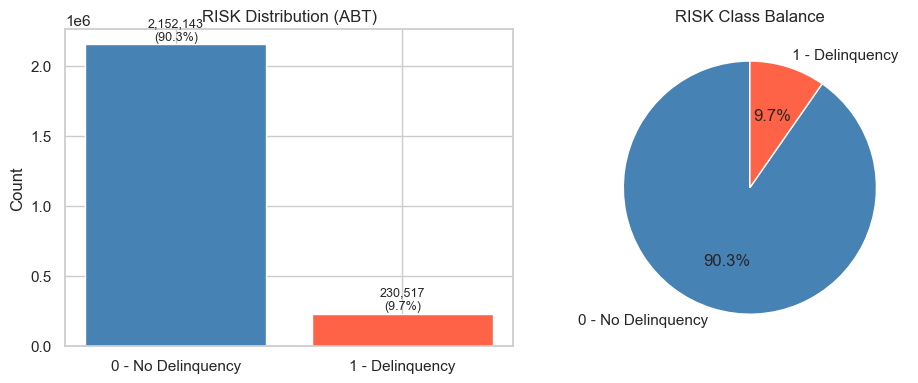


Top 10 unique RISK string values:
RISK
 0                      2152143
-9223372036854775808     116842
 10000000                  8132
 100000000                 5542
 1000000000                4997
 10000000000               4729
 100000000000              4365
 1000000000000             4086
 10000000000000            3636
 1000000000000000          3425


In [31]:
# RISK is still the raw 24-character string at this stage of the pipeline (we will later engineer it to be binary)
# We check its presence, absence of nulls, and inspect how many records carry any non-zero character (have at least 1 delinquent month)

assert "RISK" in abt.columns, "RISK column is missing!"
assert abt["RISK"].isnull().sum() == 0, "RISK has nulls — must be complete!"

# Derive a binary flag for inspection (without modifying abt)
risk_has_delinq = abt["RISK"].astype(str).str.strip().str.contains(r"[1-9]", regex=True, na=False)
n_risk    = risk_has_delinq.sum()
n_no_risk = (~risk_has_delinq).sum()
n_total   = len(abt)

print(f"RISK distribution (raw string -> binary interpretation):")
print(f"  No delinquency (all zeros) : {n_no_risk:>10,}  ({n_no_risk/n_total*100:.1f}%)")
print(f"  Has delinquency (any 1-9)  : {n_risk:>10,}  ({n_risk/n_total*100:.1f}%)")
print(f"  Imbalance ratio (0:1)      : {n_no_risk/n_risk:.1f}:1")


# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ["0 - No Delinquency", "1 - Delinquency"]
counts = [n_no_risk, n_risk]

axes[0].bar(labels, counts, color=["steelblue", "tomato"], edgecolor="white")
for i, v in enumerate(counts):
    axes[0].text(i, v + n_total * 0.005, f"{v:,}\n({v/n_total*100:.1f}%)",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_title("RISK Distribution (ABT)", fontsize=12)
axes[0].set_ylabel("Count")

axes[1].pie(counts, labels=labels, colors=["steelblue", "tomato"],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white"))
axes[1].set_title("RISK Class Balance", fontsize=12)

plt.tight_layout()
plt.show()


print(f"\nTop 10 unique RISK string values:")
print(abt["RISK"].value_counts().head(10).to_string())

### 2.7.9 Data Types & Feature Inventory

In [32]:
dtype_counts = abt.dtypes.value_counts()
print("Column dtype distribution:")
display(dtype_counts.to_frame("count"))

# Any remaining object columns (will probably need encoding later)
obj_cols = abt.select_dtypes(include="object").columns.tolist()
print(f"\nObject (string) columns : {obj_cols}")

# Full column listing
print(f"\nTotal features in ABT : {abt.shape[1]}")
print("\nAll columns:")
for i, col in enumerate(abt.columns, 1):
    print(f"  {i:3d}. {col}")

Column dtype distribution:


,count
float64,59
object,10
int64,4
datetime64[ns],3



Object (string) columns : ['CONTRIB', 'POLE', 'TYPEPROD', 'PRODALP', 'POS', 'PAGAMENTO', 'NATIO', 'MODCONTACTO', 'sdem_SITFAM', 'sdem_HABITAT']

Total features in ABT : 76

All columns:
    1. CONTRIB
    2. POLE
    3. TYPEPROD
    4. PRODALP
    5. BICONTRATO
    6. POS
    7. OBS_DATE
    8. DURDEG
    9. RANGPRO
   10. RANGCLI
   11. MTFINO
   12. MTFIN
   13. MENSALIDADE
   14. CRD
   15. SREC
   16. RN
   17. RD
   18. RISK
   19. RISKA
   20. AGFIN
   21. PAGAMENTO
   22. RESSO
   23. CSP
   24. NATIO
   25. PTT
   26. NBENF
   27. MODCONTACTO
   28. RISK_EVER
   29. RISK_RECENT
   30. MT_MENSAL
   31. COUNT_CL
   32. COUNT_CP
   33. COUNT_AUTO
   34. COUNT_HT
   35. COUNT_CONEXO
   36. COUNT_OTHER
   37. COUNT_TOTAL
   38. MONTVENC_CL
   39. MONTVENC_CP
   40. MONTVENC_AUTO
   41. MONTVENC_HT
   42. MONTABATV_CL
   43. MONTABATV_CP
   44. MONTABATV_AUTO
   45. MONTABATV_HT
   46. DIVIDAS_CL
   47. DIVIDAS_CP
   48. DIVIDAS_AUTO
   49. DIVIDAS_HT
   50. crc_total_overdue
   51.

## 2.8 Feature engineering (TO DO)


### After this process we can pass to the cool parte, encoding, scaling anddddddddd THE MODELSSSSSSSSSSS RAHHHHHHHHHHHHHH (Its 1:26 im so tired)

---
## 2.9 Feature encoding 

We apply Ordinal Encoding to variables with a natural hierarchy. This transforms risk-related categories into a numerical scale, allowing algorithms to understand the "distance" between different credit profiles without expanding the number of columns.

Transformations for nominal variables (no inherent order) are deferred to the modeling stage (notebooks 3 and 4).

---
## 2.10 Save ABT

The ABT is saved as a **Parquet file** to `../data/prepared/abt.parquet`.  
Parquet preserves dtypes and is significantly faster to read than CSV for large tables.

In [33]:
io.save(abt, ABT_OUT_PATH)

# Verify file exists and reload sanity check
import os
assert os.path.exists(ABT_OUT_PATH), "ABT file not found after save!"

abt_check = pd.read_parquet(ABT_OUT_PATH)
assert abt_check.shape == abt.shape, "Reloaded shape mismatch!"
print(f"\nABT successfully saved and verified: {ABT_OUT_PATH}")
print(f"   Rows: {abt_check.shape[0]:,}  |  Columns: {abt_check.shape[1]}")

[SAVE] ../data/prepared/abt.parquet | shape: (2382660, 76)

ABT successfully saved and verified: ../data/prepared/abt.parquet
   Rows: 2,382,660  |  Columns: 76


---
## 2.11 Subset ABT for the First Objective

We subset the `abt` dataset to include only customers whose **point-of-sale channel** (`POS`) lies in `SAN` or `SOL`.  
For each of those customers, we:
1. Create a binary flag `IS_SAN` (1 = SAN, 0 = SOL).
2. Keep only the **most recent** `SAN` record (if they have any `SAN` transactions).  
3. If they don't have any `SAN` transactions but only `SOL`, we keep their **most recent** `SOL` record.

This subset is stored as `abt_first_objective` and forms the baseline for the first modelling task.

In [34]:
# 1. Filter to only SAN or SOL
df_subset = abt[abt["POS"].isin(["SAN", "SOL"])].copy()

# 2. Create the flag IS_SAN (focus of this objetive)
df_subset["IS_SAN"] = (df_subset["POS"] == "SAN").astype(int)

# 3. Sort logic:
#    a) CONTRIB defines the customer group
#    b) IS_SAN (Descending) ensures SAN (1) always comes before SOL (0)
#    c) OBS_DATE (Descending) ensures most recent dates come first
df_subset = df_subset.sort_values(
    by=["CONTRIB", "IS_SAN", "OBS_DATE"], 
    ascending=[True, False, False]
)

# 4. Drop duplicates by CONTRIB, keeping the first row (the best one according to our sort)
abt_first_objective = df_subset.drop_duplicates(subset=["CONTRIB"], keep="first").copy()

print(f"Original ABT shape    : {abt.shape}")
print(f"Subset ABT shape      : {abt_first_objective.shape}")
print(f"Unique customers kept : {abt_first_objective['CONTRIB'].nunique()}") # just making sure there are no duplicates left
print("\nIS_SAN distribution:")
print(f"{abt_first_objective['IS_SAN'].value_counts(normalize=True).round(4) * 100}")

Original ABT shape    : (2382660, 76)
Subset ABT shape      : (64707, 77)
Unique customers kept : 64707

IS_SAN distribution:
IS_SAN
1   59.850
0   40.150
Name: proportion, dtype: float64


In [35]:
# Quick check of the resulting subset
display(abt_first_objective[["CONTRIB", "POS", "OBS_DATE", "IS_SAN"]].head())

,CONTRIB,POS,OBS_DATE,IS_SAN
878898,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,SAN,2025-11-30,1
2126002,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,SOL,2024-08-31,0
1933953,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,SAN,2024-12-31,1
2126006,000406feeb8088e3b05f47bc89160d25ca14f11c31f91b...,SOL,2024-08-31,0
878902,000508d6436a34b780df1aa8068568f1b118f5d589ddc7...,SOL,2025-11-30,0


In [36]:
# Save the subsetted ABT
ABT_FIRST_OUT_PATH = "../data/prepared/abt_first_objective.parquet"
io.save(abt_first_objective, ABT_FIRST_OUT_PATH)

[SAVE] ../data/prepared/abt_first_objective.parquet | shape: (64707, 77)
